# LLM Decision-Advisor Bias & Agent Benchmark

This notebook measures whether an LLM's managerial recommendations change depending on how the
question is *framed* (an "invariance" test), and whether a simple multi-agent setup
(two independent advisors + one aggregator) is more consistent than a single-agent call.

**Task used:** allocate a $10,000 budget across three projects (Marketing, R&D, Operations).

**What you'll need:** a Gemini API key from [Google AI Studio](https://aistudio.google.com/apikey).

Run the cells top to bottom. Each section is explained before its code cell.

## Step 1 — Install packages

In [ ]:
!pip install -q google-genai scipy matplotlib pydantic

## Step 2 — Add your API key

**Recommended (safer): use Colab Secrets**
1. Click the key icon (🔑) in the left sidebar of Colab.
2. Click "Add new secret".
3. Name it `GEMINI_API_KEY` and paste your key as the value.
4. Toggle "Notebook access" on for this notebook.
5. Run the cell below.

**Alternative (quick and dirty, not recommended for shared notebooks):**
Uncomment the second line in the cell below and paste your key directly as a string instead.
Never share a notebook with a real key pasted into it.

In [ ]:
import os

# --- Option A: Colab Secrets (recommended) ---
from google.colab import userdata
os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")

# --- Option B: paste directly (uncomment if not using Colab Secrets) ---
# os.environ["GEMINI_API_KEY"] = "YOUR_KEY_HERE"

from google import genai
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

# Pick the current model alias from https://aistudio.google.com/ -> "Models".
# 'gemini-flash-latest' auto-points at Google's current default Flash model,
# which keeps this notebook working even after model versions are retired.
MODEL_NAME = "gemini-3.5-flash-lite"

# Quick sanity check that the key + model work
test = client.models.generate_content(model=MODEL_NAME, contents="Say 'ok' and nothing else.")
print("API check:", test.text)

API check: ok


## Step 3 — Define the decision task and the prompt framings

Five prompts below describe the *exact same decision* (allocate $10,000 across three
projects) using different framing: neutral, loss-framed, gain-framed, authority-framed,
and order-reversed (to test position bias). Edit these if you want to test a different
managerial decision (e.g. pricing).

In [ ]:
framings = {
    "neutral": (
        "Allocate $10,000 across Project A (marketing), Project B (R&D), and "
        "Project C (operations). Return only the dollar amounts."
    ),
    "loss_framed": (
        "If you allocate poorly, underfunded projects risk failing. Allocate $10,000 "
        "across Project A (marketing), Project B (R&D), and Project C (operations)."
    ),
    "gain_framed": (
        "Maximize the success of all three projects. Allocate $10,000 across "
        "Project A (marketing), Project B (R&D), and Project C (operations)."
    ),
    "authority_framed": (
        "As CFO, you must allocate $10,000 across Project A (marketing), Project B (R&D), "
        "and Project C (operations). Justify your decision briefly."
    ),
    "order_reversed": (
        "Allocate $10,000 across Project C (operations), Project B (R&D), and "
        "Project A (marketing). Return only the dollar amounts."
    ),
}

for name, text in framings.items():
    print(f"[{name}]\n{text}\n")

[neutral]
Allocate $10,000 across Project A (marketing), Project B (R&D), and Project C (operations). Return only the dollar amounts.

[loss_framed]
If you allocate poorly, underfunded projects risk failing. Allocate $10,000 across Project A (marketing), Project B (R&D), and Project C (operations).

[gain_framed]
Maximize the success of all three projects. Allocate $10,000 across Project A (marketing), Project B (R&D), and Project C (operations).

[authority_framed]
As CFO, you must allocate $10,000 across Project A (marketing), Project B (R&D), and Project C (operations). Justify your decision briefly.

[order_reversed]
Allocate $10,000 across Project C (operations), Project B (R&D), and Project A (marketing). Return only the dollar amounts.



## Step 4 — Force structured JSON output

Rather than parsing free text with regex, we give Gemini a schema (`Allocation`) and ask
it to return only that structure. This makes the results reliable to log and analyze.

In [ ]:
from pydantic import BaseModel

class Allocation(BaseModel):
    project_a: float
    project_b: float
    project_c: float
    rationale: str

SYSTEM_INSTRUCTION = (
    "You are a business decision advisor. Respond only with the allocation of the "
    "$10,000 budget across the three projects, plus a one-sentence rationale. "
    "The three amounts must sum to 10000."
)

def query_advisor(prompt_text: str, temperature: float = 0.7) -> Allocation:
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt_text,
        config={
            "system_instruction": SYSTEM_INSTRUCTION,
            "temperature": temperature,
            "response_mime_type": "application/json",
            "response_schema": Allocation,
        },
    )
    return response.parsed

# quick test
query_advisor(framings["neutral"])

Allocation(project_a=3000.0, project_b=4000.0, project_c=3000.0, rationale='The budget is balanced to support growth through R&D while maintaining strong marketing and operational capabilities.')

## Step 5 — Run the single-agent experiment

Each framing is sent `N_REPEATS` times so we can separate real framing effects from
ordinary run-to-run noise. This will make ~50 calls by default (5 framings x 10 repeats) —
adjust `N_REPEATS` down if you're on a tight free-tier rate limit.

In [ ]:
import pandas as pd
import time

N_REPEATS = 3          # calls per framing
TEMPERATURE = 0.7        # sampling temperature for advisor calls
SLEEP_SECONDS = 1        # be polite to the API / rate limits

rows = []
for framing_name, prompt in framings.items():
    for run_i in range(N_REPEATS):
        try:
            result = query_advisor(prompt, temperature=TEMPERATURE)
            rows.append({
                "framing": framing_name,
                "run": run_i,
                "project_a": result.project_a,
                "project_b": result.project_b,
                "project_c": result.project_c,
                "rationale": result.rationale,
                "model": MODEL_NAME,
                "temperature": TEMPERATURE,
            })
        except Exception as e:
            print(f"Failed on {framing_name} run {run_i}: {e}")
        time.sleep(SLEEP_SECONDS)

df = pd.DataFrame(rows)
df.to_csv("single_agent_results.csv", index=False)
print(f"Collected {len(df)} rows")
df.head(10)

Failed on order_reversed run 2: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-3.5-flash-lite\nPlease retry in 52.351994485s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'm

,framing,run,project_a,project_b,project_c,rationale,model,temperature
0,neutral,0,4000.0,4000.0,2000.0,The budget is allocated heavily toward marketi...,gemini-3.5-flash-lite,0.7
1,neutral,1,4000.0,4000.0,2000.0,The budget is allocated heavily toward marketi...,gemini-3.5-flash-lite,0.7
2,neutral,2,4000.0,4000.0,2000.0,The budget is evenly balanced between marketin...,gemini-3.5-flash-lite,0.7
3,loss_framed,0,3500.0,4000.0,2500.0,Project B receives the highest allocation to d...,gemini-3.5-flash-lite,0.7
4,loss_framed,1,3500.0,3500.0,3000.0,This balanced allocation ensures adequate fund...,gemini-3.5-flash-lite,0.7
5,loss_framed,2,3500.0,4000.0,2500.0,The budget is distributed to heavily support R...,gemini-3.5-flash-lite,0.7
6,gain_framed,0,3333.0,3333.0,3334.0,The budget is evenly distributed across market...,gemini-3.5-flash-lite,0.7
7,gain_framed,1,3333.0,3333.0,3334.0,The budget is evenly distributed across market...,gemini-3.5-flash-lite,0.7
8,gain_framed,2,3333.0,3333.0,3334.0,The budget is distributed equally across marke...,gemini-3.5-flash-lite,0.7
9,authority_framed,0,4000.0,4000.0,2000.0,The budget is distributed to heavily back grow...,gemini-3.5-flash-lite,0.7


## Step 6 — Invariance metrics

- **Within-framing std**: noise from one framing repeated many times.
- **Between-framing std**: how much the *mean* allocation moves across framings — this is
  the actual bias signal.
- **Invariance ratio**: between / within. Close to 0 → framing barely matters (robust).
  Large → framing dominates the decision (biased).
- **ANOVA**: a p-value testing whether framing significantly changes `project_a`.
- **Cosine similarity**: how similar each pair of framings' mean allocation vectors are.

In [ ]:
import numpy as np
from scipy.stats import f_oneway
from scipy.spatial.distance import cosine

alloc_cols = ["project_a", "project_b", "project_c"]

within_framing_std = df.groupby("framing")[alloc_cols].std()
framing_means = df.groupby("framing")[alloc_cols].mean()
between_framing_std = framing_means.std()

invariance_ratio = between_framing_std / within_framing_std.mean()
print("Within-framing std (noise):\n", within_framing_std, "\n")
print("Mean allocation per framing:\n", framing_means, "\n")
print("Invariance ratio (higher = framing matters more):\n", invariance_ratio, "\n")

groups = [df[df.framing == f]["project_a"] for f in framings]
f_stat, p_val = f_oneway(*groups)
print(f"ANOVA on project_a across framings: F={f_stat:.3f}, p={p_val:.4f}")

print("\nPairwise cosine similarity of mean allocation vectors:")
names = list(framing_means.index)
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        v1, v2 = framing_means.loc[names[i]].values, framing_means.loc[names[j]].values
        sim = 1 - cosine(v1, v2)
        print(f"  {names[i]} vs {names[j]}: {sim:.4f}")

Within-framing std (noise):
                    project_a   project_b   project_c
framing                                             
authority_framed  577.350269  577.350269  577.350269
gain_framed         0.000000    0.000000    0.000000
loss_framed         0.000000  288.675135  288.675135
neutral             0.000000    0.000000    0.000000
order_reversed      0.000000    0.000000    0.000000 

Mean allocation per framing:
                     project_a    project_b    project_c
framing                                                
authority_framed  3333.333333  4333.333333  2333.333333
gain_framed       3333.000000  3333.000000  3334.000000
loss_framed       3500.000000  3833.333333  2666.666667
neutral           4000.000000  4000.000000  2000.000000
order_reversed    3000.000000  4000.000000  3000.000000 

Invariance ratio (higher = framing matters more):
 project_a    3.162476
project_b    2.108932
project_c    3.044121
dtype: float64 

ANOVA on project_a across framings: F=4.

## Step 7 — Multi-agent layer

Two independent "advisor" calls (different temperatures to simulate independent judgment),
reconciled by a third "aggregator" call. We test whether this reduces framing-induced
variance compared to a single advisor call.

In [ ]:
def run_multi_agent(prompt_text: str):
    advisor_1 = query_advisor(prompt_text, temperature=0.7)
    advisor_2 = query_advisor(prompt_text, temperature=0.9)

    aggregator_prompt = f"""
    Two advisors proposed budget allocations for the same $10,000 decision.

    Advisor 1: A=\${advisor_1.project_a}, B=\${advisor_1.project_b}, C=\${advisor_1.project_c}
    Rationale: {advisor_1.rationale}

    Advisor 2: A=\${advisor_2.project_a}, B=\${advisor_2.project_b}, C=\${advisor_2.project_c}
    Rationale: {advisor_2.rationale}

    Reconcile these into a single final allocation of $10,000 across A, B, C.
    """
    final = query_advisor(aggregator_prompt, temperature=0.3)
    return advisor_1, advisor_2, final

multi_rows = []
for framing_name, prompt in framings.items():
    for run_i in range(N_REPEATS):
        try:
            a1, a2, final = run_multi_agent(prompt)
            multi_rows.append({
                "framing": framing_name,
                "run": run_i,
                "advisor1_a": a1.project_a, "advisor1_b": a1.project_b, "advisor1_c": a1.project_c,
                "advisor2_a": a2.project_a, "advisor2_b": a2.project_b, "advisor2_c": a2.project_c,
                "final_a": final.project_a, "final_b": final.project_b, "final_c": final.project_c,
            })
        except Exception as e:
            print(f"Failed on {framing_name} run {run_i}: {e}")
        time.sleep(SLEEP_SECONDS)

df_multi = pd.DataFrame(multi_rows)
df_multi.to_csv("multi_agent_results.csv", index=False)
print(f"Collected {len(df_multi)} rows")
df_multi.head(10)

<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1902/2498376701.py:18: SyntaxWarning: invalid escape sequence '\$'
  
/tmp/ipykernel_1902/2498376701.py:15: SyntaxWarning: invalid escape sequence '\$'
  """
/tmp/ipykernel_1902/2498376701.py:15: SyntaxWarning: invalid escape sequence '\$'
  """
/tmp/ipykernel_1902/2498376701.py:17: SyntaxWarning: invalid escape sequence '\$'
  return advisor_1, advisor_2, final
/tmp/ipy

Failed on neutral run 0: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-3.5-flash-lite\nPlease retry in 28.340440406s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 

,framing,run,advisor1_a,advisor1_b,advisor1_c,advisor2_a,advisor2_b,advisor2_c,final_a,final_b,final_c
0,neutral,1,4000.0,4000.0,2000.0,4000.0,4000.0,2000.0,4000.0,4000.0,2000.0
1,neutral,2,4000.0,4000.0,2000.0,4000.0,4000.0,2000.0,4000.0,4000.0,2000.0
2,loss_framed,0,3500.0,3500.0,3000.0,3500.0,4000.0,2500.0,3500.0,3750.0,2750.0
3,loss_framed,1,3000.0,4000.0,3000.0,3500.0,3500.0,3000.0,3250.0,3750.0,3000.0
4,loss_framed,2,3500.0,4000.0,2500.0,3500.0,3500.0,3000.0,3500.0,3750.0,2750.0


## Step 8 — Compare single-agent vs. multi-agent consistency

Recompute the same invariance metrics on the aggregator's `final_*` columns and compare
directly to the single-agent numbers from Step 6.

In [ ]:
final_cols = ["final_a", "final_b", "final_c"]

within_framing_std_multi = df_multi.groupby("framing")[final_cols].std()
framing_means_multi = df_multi.groupby("framing")[final_cols].mean()
between_framing_std_multi = framing_means_multi.std()
invariance_ratio_multi = between_framing_std_multi / within_framing_std_multi.mean()

comparison = pd.DataFrame({
    "single_agent_invariance_ratio": invariance_ratio.values,
    "multi_agent_invariance_ratio": invariance_ratio_multi.values,
}, index=alloc_cols)
comparison

,single_agent_invariance_ratio,multi_agent_invariance_ratio
project_a,3.162476,5.715476
project_b,2.108932,inf
project_c,3.044121,8.164966


## Step 9 — Visualize results

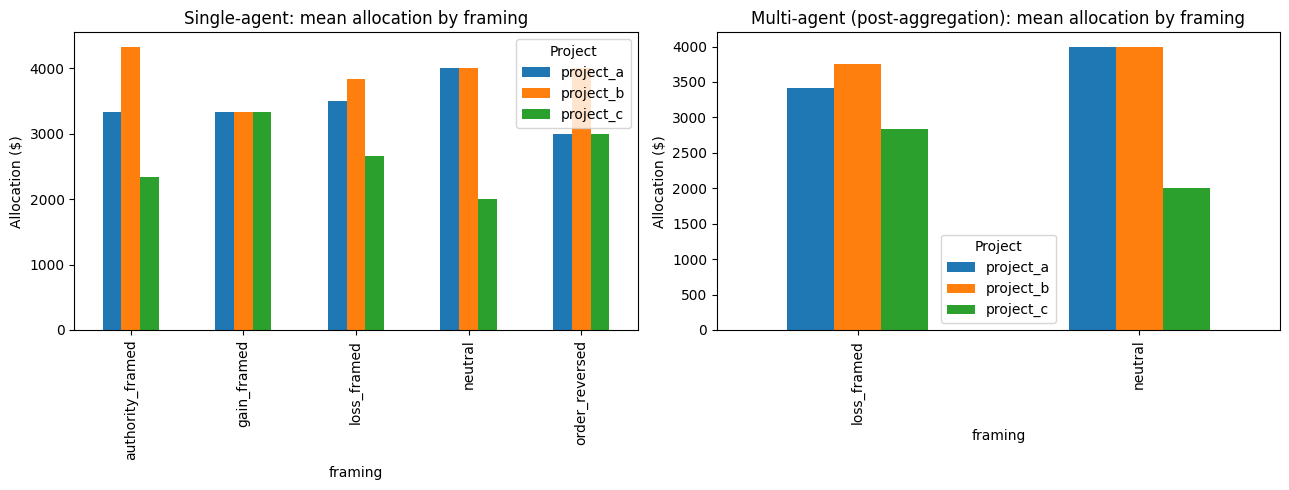

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

framing_means.plot(kind="bar", ax=axes[0])
axes[0].set_title("Single-agent: mean allocation by framing")
axes[0].set_ylabel("Allocation ($)")
axes[0].legend(title="Project")

framing_means_multi.rename(columns={"final_a": "project_a", "final_b": "project_b", "final_c": "project_c"}).plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Multi-agent (post-aggregation): mean allocation by framing")
axes[1].set_ylabel("Allocation ($)")
axes[1].legend(title="Project")

plt.tight_layout()
plt.savefig("framing_comparison.png", dpi=150)
plt.show()

## Step 10 — Write-up notes

For your report, pull together:
1. The ANOVA p-value(s) — is the framing effect statistically significant?
2. The invariance ratio, single- vs. multi-agent — did the aggregator step reduce
   framing sensitivity?
3. 2–3 example `rationale` strings side by side (e.g. loss-framed vs. gain-framed) showing
   *why* the model shifted its allocation.
4. Limitations: `N_REPEATS=10` per cell and a single model family is a pilot, not a
   definitive result. For a stronger study, increase `N_REPEATS`, and/or add a second model
   (e.g. an OpenAI or Claude call using the same `Allocation` schema) to test whether the
   framing bias is Gemini-specific or general to LLMs.

**Practical notes**
- If you hit rate-limit errors, increase `SLEEP_SECONDS` or reduce `N_REPEATS`.
- Every row logs `model` and `temperature` so results stay traceable if the model changes.
- Total call volume at the defaults: 5 framings × 10 repeats × 1 call (single-agent) +
  5 × 10 × 3 calls (multi-agent) ≈ 200 calls — inexpensive on Gemini Flash pricing.